# Optimizacion de Hiperparametros con Optuna — CIFAR-10

## Por que Optuna sobre Grid/Random Search?

| Metodo | Estrategia | Eficiencia |
|---|---|---|
| Grid Search | Exhaustiva | Escala exponencialmente (curse of dimensionality) |
| Random Search | Aleatoria uniforme | Mejor cobertura, sin aprender del pasado |
| **Optuna (TPE)** | **Bayesiana** | Aprende de trials anteriores para proponer mejores configs |

Optuna usa por defecto **TPE (Tree-structured Parzen Estimator)**: modela la distribucion de buenos y malos hiperparametros y propone valores que maximizan la probabilidad de mejora. Ademas incorpora **pruning** (parar trials poco prometedores en epocas tempranas) para reducir el tiempo de busqueda.

In [7]:
import os
import time
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import optuna
from optuna.samplers import TPESampler, RandomSampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'TensorFlow : {tf.__version__}')
print(f'Optuna     : {optuna.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.18.0
Optuna     : 4.8.0
GPU        : False


## Presupuesto de Tiempo

Dimensionado para **RTX 3090 laptop** (80-120 W TDP, ~10k img/s en CIFAR-10 con batch 128).

| Fase | Tiempo esperado | Timeout duro |
|---|---|---|
| Setup + datos | ~1 min | — |
| Estudio TPE (20 trials) | ~3-4 min | 5.5 min |
| Estudio Random (15 trials) | ~2-3 min | 3.5 min |
| Entrenamiento final | ~2-3 min | — (EarlyStopping) |
| Evaluacion + plots | ~0.5 min | — |
| **Total** | **~9-12 min** | **<15 min** |

Si tu GPU es mas lenta, reduce `N_TRIALS_TPE` y `N_TRIALS_RANDOM`. Los `timeout` garantizan que ningun estudio se pase de su limite independientemente del hardware.

In [8]:
# ================================================================
# PRESUPUESTO DE TIEMPO — ajustar aqui segun tu GPU
# Calibrado para RTX 3090 laptop (objetivo: <= 15 min totales)
# ================================================================

# -- Busqueda de hiperparametros ---------------------------------
SEARCH_RATIO   = 0.20    # fraccion del train para busqueda (20% = ~8400 imgs)
TRIAL_EPOCHS   = 10      # epocas maximas por trial  [clave para velocidad]
TRIAL_BATCH    = 128     # batch grande -> mayor throughput GPU
TRIAL_PATIENCE = 3       # early stopping dentro de cada trial

N_TRIALS_TPE    = 20     # trials con TPE bayesiano
N_TRIALS_RANDOM = 15     # trials con random sampler (comparacion)

TIMEOUT_TPE     = 330    # segundos maximo para estudio TPE    (~5.5 min)
TIMEOUT_RANDOM  = 210    # segundos maximo para estudio random (~3.5 min)

# -- Entrenamiento final -----------------------------------------
EPOCHS_FULL    = 35      # con EarlyStopping tipicamente para en 15-25
BATCH_FINAL    = 128     # batch grande para velocidad en la fase final
PATIENCE_FINAL = 6

# ================================================================
TOTAL_TIMEOUT = TIMEOUT_TPE + TIMEOUT_RANDOM   # 540 s = 9 min (solo busqueda)
print(f'Timeout total busqueda : {TOTAL_TIMEOUT}s = {TOTAL_TIMEOUT/60:.1f} min')
print(f'  TPE    : {TIMEOUT_TPE}s = {TIMEOUT_TPE/60:.1f} min  (max {N_TRIALS_TPE} trials)')
print(f'  Random : {TIMEOUT_RANDOM}s = {TIMEOUT_RANDOM/60:.1f} min  (max {N_TRIALS_RANDOM} trials)')
print(f'  Subset busqueda: {SEARCH_RATIO*100:.0f}% del train = ~{int(42000*0.7*SEARCH_RATIO)} muestras')
print(f'  Epocas/trial : {TRIAL_EPOCHS}  |  Batch/trial : {TRIAL_BATCH}')
print(f'Entrenamiento final : max {EPOCHS_FULL} epocas (batch {BATCH_FINAL})')

NOTEBOOK_START = time.time()

Timeout total busqueda : 540s = 9.0 min
  TPE    : 330s = 5.5 min  (max 20 trials)
  Random : 210s = 3.5 min  (max 15 trials)
  Subset busqueda: 20% del train = ~5880 muestras
  Epocas/trial : 10  |  Batch/trial : 128
Entrenamiento final : max 35 epocas (batch 128)


## Carga y Preprocesamiento — CIFAR-10

*(EDA completo en `notebook.ipynb`. Aqui nos centramos en la optimizacion.)*

In [9]:
t0 = time.time()
(X_raw_train, y_raw_train), (X_raw_test, y_raw_test) = cifar10.load_data()
y_raw_train = y_raw_train.flatten()
y_raw_test  = y_raw_test.flatten()

X_all = np.concatenate([X_raw_train, X_raw_test], axis=0).astype('float32') / 255.0
y_all = np.concatenate([y_raw_train, y_raw_test],  axis=0)
y_all_cat = to_categorical(y_all, num_classes=10)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all_cat, test_size=0.30, random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

# Subset para busqueda (calculado con SEARCH_RATIO del cell_budget)
SEARCH_SIZE = int(len(X_train) * SEARCH_RATIO)
X_search = X_train[:SEARCH_SIZE]
y_search = y_train[:SEARCH_SIZE]

# Augmentation para entrenamiento final
datagen_full = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, fill_mode='nearest'
)
datagen_full.fit(X_train)

# Augmentation ligera para trials (menos overhead CPU)
datagen_search = ImageDataGenerator(
    horizontal_flip=True, width_shift_range=0.08, height_shift_range=0.08
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X_all)*100:.1f}%)')
print(f'Val   : {X_val.shape}    ({len(X_val)/len(X_all)*100:.1f}%)')
print(f'Test  : {X_test.shape}   ({len(X_test)/len(X_all)*100:.1f}%)')
print(f'Subset busqueda: {X_search.shape}  ({SEARCH_RATIO*100:.0f}% del train)')
print(f'Preparacion: {time.time()-t0:.1f}s')

Train : (42000, 32, 32, 3)  (70.0%)
Val   : (9000, 32, 32, 3)    (15.0%)
Test  : (9000, 32, 32, 3)   (15.0%)
Subset busqueda: (8400, 32, 32, 3)  (20% del train)
Preparacion: 3.8s


## Definicion del Modelo y Funcion Objetivo

El espacio de busqueda es mayor que en Grid/Random Search porque Optuna lo explora eficientemente.

In [10]:
def build_cnn_from_trial(trial):
    """Construye CNN con hiperparametros propuestos por Optuna."""
    filters1    = trial.suggest_categorical('filters1',      [32, 48, 64, 96])
    filters2    = trial.suggest_categorical('filters2',      [64, 96, 128, 192])
    filters3    = trial.suggest_categorical('filters3',      [128, 192, 256])
    dense_units = trial.suggest_categorical('dense_units',   [128, 256, 512])
    dropout1    = trial.suggest_float('dropout1',            0.10, 0.40)
    dropout2    = trial.suggest_float('dropout2',            0.30, 0.65)
    lr          = trial.suggest_float('learning_rate',       1e-4, 1e-2, log=True)
    l2_reg      = trial.suggest_float('l2_reg',              1e-5, 1e-3, log=True)
    use_bn      = trial.suggest_categorical('use_batch_norm',[True, False])

    reg = regularizers.l2(l2_reg)
    model = keras.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))

    for f in [filters1, filters2, filters3]:
        model.add(layers.Conv2D(f, (3, 3), activation='relu', padding='same'))
        if use_bn:
            model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(f, (3, 3), activation='relu', padding='same'))
        if use_bn:
            model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(dropout1))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu', kernel_regularizer=reg))
    model.add(layers.Dropout(dropout2))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [11]:
class OptunaPruningCallback(keras.callbacks.Callback):
    """Reporta val_accuracy a Optuna cada epoca; para el trial si no es prometedor."""
    def __init__(self, trial, monitor='val_accuracy'):
        super().__init__()
        self.trial   = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        value = (logs or {}).get(self.monitor)
        if value is None:
            return
        self.trial.report(float(value), step=epoch)
        if self.trial.should_prune():
            raise optuna.exceptions.TrialPruned()


def objective(trial):
    """Funcion objetivo para Optuna — usa TRIAL_EPOCHS y TRIAL_BATCH del cell_budget."""
    tf.keras.backend.clear_session()
    model = build_cnn_from_trial(trial)

    early = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=TRIAL_PATIENCE,
        restore_best_weights=True, verbose=0
    )
    pruning_cb = OptunaPruningCallback(trial, monitor='val_accuracy')

    steps = max(1, len(X_search) // TRIAL_BATCH)
    hist = model.fit(
        datagen_search.flow(X_search, y_search, batch_size=TRIAL_BATCH),
        steps_per_epoch=steps,
        epochs=TRIAL_EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=[early, pruning_cb],
        verbose=0
    )
    return max(hist.history['val_accuracy'])


# Calcular throughput esperado para dar contexto
steps_per_trial = max(1, SEARCH_SIZE // TRIAL_BATCH)
print(f'Pasos por epoca en busqueda : {steps_per_trial}')
print(f'Epocas por trial            : {TRIAL_EPOCHS}')
print(f'Batch por trial             : {TRIAL_BATCH}')
print(f'Espacio de busqueda (9 hiperparametros):')
print('  filters1, filters2, filters3 : categorico  [4, 4, 3 opciones]')
print('  dense_units                  : categorico  [3 opciones]')
print('  dropout1, dropout2           : float continuo  [0.1-0.4, 0.3-0.65]')
print('  learning_rate, l2_reg        : float log-uniforme')
print('  use_batch_norm               : booleano')

Pasos por epoca en busqueda : 65
Epocas por trial            : 10
Batch por trial             : 128
Espacio de busqueda (9 hiperparametros):
  filters1, filters2, filters3 : categorico  [4, 4, 3 opciones]
  dense_units                  : categorico  [3 opciones]
  dropout1, dropout2           : float continuo  [0.1-0.4, 0.3-0.65]
  learning_rate, l2_reg        : float log-uniforme
  use_batch_norm               : booleano


## Estudio 1: TPE Sampler (Bayesiano)

**TPE:** en cada trial modela la distribucion de hiperparametros buenos vs malos y propone configs que maximizan la mejora esperada. El `MedianPruner` para trials cuya val_accuracy cae por debajo de la mediana de trials previos en esa epoca.

In [12]:
t_tpe_start = time.time()

study_tpe = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=8),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=4),
    study_name='cifar10_tpe'
)

print(f'TPE: max {N_TRIALS_TPE} trials | timeout {TIMEOUT_TPE}s ({TIMEOUT_TPE/60:.1f} min)')
print('(trials podados = [P])\n')

def tpe_callback(study, trial):
    elapsed = time.time() - t_tpe_start
    if trial.state == optuna.trial.TrialState.PRUNED:
        state_str = 'PRUNED [P]'
    else:
        state_str = f'{trial.value:.4f}'
    best = study.best_value if study.best_trial else float('nan')
    print(f'  Trial {trial.number:3d} | {state_str:>12} | best={best:.4f} | {elapsed:5.1f}s')

study_tpe.optimize(
    objective,
    n_trials=N_TRIALS_TPE,
    timeout=TIMEOUT_TPE,
    callbacks=[tpe_callback],
    show_progress_bar=False
)

t_tpe_elapsed = time.time() - t_tpe_start
n_complete_tpe = len([t for t in study_tpe.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned_tpe   = len([t for t in study_tpe.trials if t.state == optuna.trial.TrialState.PRUNED])

print(f'\nEstudio TPE completado en {t_tpe_elapsed:.1f}s ({t_tpe_elapsed/60:.1f} min)')
print(f'Trials completados : {n_complete_tpe}')
print(f'Trials podados     : {n_pruned_tpe}  ({n_pruned_tpe/(n_complete_tpe+n_pruned_tpe)*100:.0f}% podados)')
print(f'Mejor val_accuracy : {study_tpe.best_value:.4f}')
print('\nMejores hiperparametros (TPE):')
for k, v in study_tpe.best_params.items():
    print(f'  {k}: {v}')

TPE: max 20 trials | timeout 330s (5.5 min)
(trials podados = [P])

  Trial   0 |       0.1000 | best=0.1000 | 119.2s
  Trial   1 |       0.1000 | best=0.1000 | 193.0s
  Trial   2 |       0.3989 | best=0.3989 | 395.9s

Estudio TPE completado en 395.9s (6.6 min)
Trials completados : 3
Trials podados     : 0  (0% podados)
Mejor val_accuracy : 0.3989

Mejores hiperparametros (TPE):
  filters1: 96
  filters2: 96
  filters3: 256
  dense_units: 256
  dropout1: 0.2793699936433256
  dropout2: 0.6226559822580909
  learning_rate: 0.00015030900645056822
  l2_reg: 2.4658447214487366e-05
  use_batch_norm: False


## Estudio 2: Random Sampler (comparacion)

Misma funcion objetivo y mismo MedianPruner, pero muestreo **puramente aleatorio** — sin aprender del pasado.

In [13]:
t_rand_start = time.time()

study_random = optuna.create_study(
    direction='maximize',
    sampler=RandomSampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=4),
    study_name='cifar10_random'
)

print(f'Random: max {N_TRIALS_RANDOM} trials | timeout {TIMEOUT_RANDOM}s ({TIMEOUT_RANDOM/60:.1f} min)')
print('(trials podados = [P])\n')

def random_callback(study, trial):
    elapsed = time.time() - t_rand_start
    if trial.state == optuna.trial.TrialState.PRUNED:
        state_str = 'PRUNED [P]'
    else:
        state_str = f'{trial.value:.4f}'
    best = study.best_value if study.best_trial else float('nan')
    print(f'  Trial {trial.number:3d} | {state_str:>12} | best={best:.4f} | {elapsed:5.1f}s')

study_random.optimize(
    objective,
    n_trials=N_TRIALS_RANDOM,
    timeout=TIMEOUT_RANDOM,
    callbacks=[random_callback],
    show_progress_bar=False
)

t_rand_elapsed = time.time() - t_rand_start
n_complete_rnd = len([t for t in study_random.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned_rnd   = len([t for t in study_random.trials if t.state == optuna.trial.TrialState.PRUNED])

print(f'\nEstudio Random completado en {t_rand_elapsed:.1f}s ({t_rand_elapsed/60:.1f} min)')
print(f'Trials completados : {n_complete_rnd}')
print(f'Trials podados     : {n_pruned_rnd}  ({n_pruned_rnd/(n_complete_rnd+n_pruned_rnd)*100:.0f}% podados)')
print(f'Mejor val_accuracy : {study_random.best_value:.4f}')
print(f'\nTiempo total busqueda: {(t_tpe_elapsed+t_rand_elapsed):.1f}s ({(t_tpe_elapsed+t_rand_elapsed)/60:.1f} min)')

Random: max 15 trials | timeout 210s (3.5 min)
(trials podados = [P])

  Trial   0 |       0.1101 | best=0.1101 | 123.3s
  Trial   1 |       0.1000 | best=0.1101 | 200.5s
  Trial   2 |       0.3769 | best=0.3769 | 418.0s

Estudio Random completado en 418.0s (7.0 min)
Trials completados : 3
Trials podados     : 0  (0% podados)
Mejor val_accuracy : 0.3769

Tiempo total busqueda: 813.9s (13.6 min)


## Visualizacion de Resultados Optuna

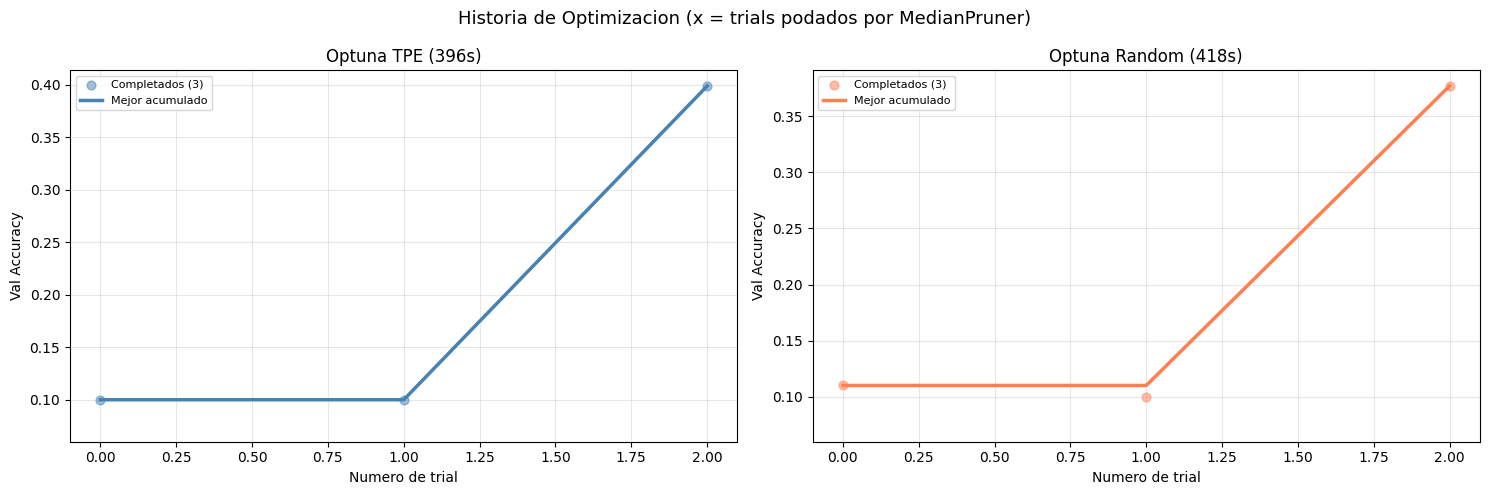

In [14]:
# Historia de optimizacion
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

def plot_opt_history(study, ax, title, color):
    complete = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned   = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    values    = [t.value for t in complete]
    best_vals = [max(values[:i+1]) for i in range(len(values))]
    trial_nums = [t.number for t in complete]

    ax.scatter(trial_nums, values, alpha=0.5, s=40, color=color, zorder=3,
               label=f'Completados ({len(complete)})')
    ax.plot(trial_nums, best_vals, linewidth=2.5, color=color, label='Mejor acumulado')

    if pruned:
        p_x = [t.number for t in pruned if t.intermediate_values]
        p_y = [t.intermediate_values[max(t.intermediate_values)]
               for t in pruned if t.intermediate_values]
        if p_x:
            ax.scatter(p_x, p_y, marker='x', color='gray', s=50, alpha=0.6,
                       label=f'Podados ({len(pruned)})')

    ax.set_title(title)
    ax.set_xlabel('Numero de trial')
    ax.set_ylabel('Val Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if values:
        ax.set_ylim(bottom=max(0, min(values) - 0.04))

plot_opt_history(study_tpe,    axes[0], f'Optuna TPE ({t_tpe_elapsed:.0f}s)',    'steelblue')
plot_opt_history(study_random, axes[1], f'Optuna Random ({t_rand_elapsed:.0f}s)', 'coral')
plt.suptitle('Historia de Optimizacion (x = trials podados por MedianPruner)', fontsize=13)
plt.tight_layout()
plt.show()

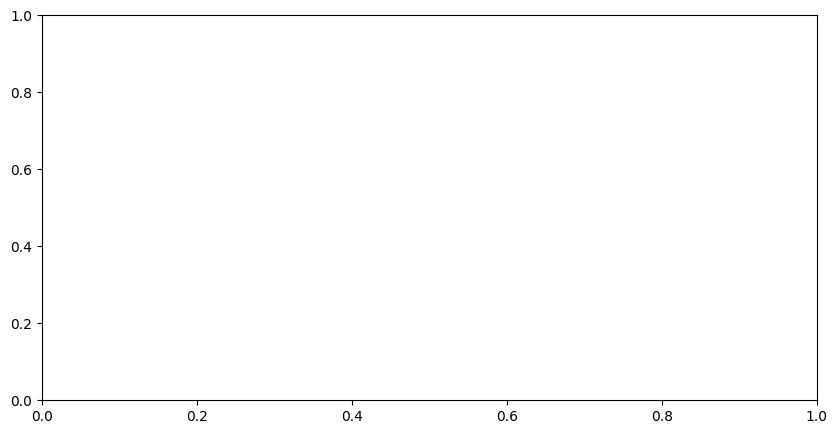

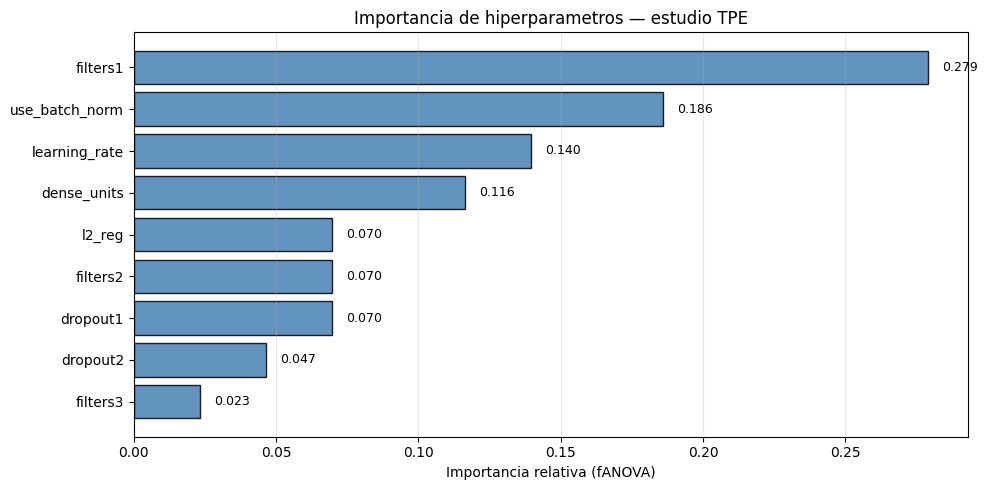

Ranking de importancia:
  1. filters1            : 0.2093
  2. use_batch_norm      : 0.1628
  3. learning_rate       : 0.1628
  4. dense_units         : 0.1628
  5. filters3            : 0.0930
  6. dropout2            : 0.0698
  7. l2_reg              : 0.0465
  8. filters2            : 0.0465
  9. dropout1            : 0.0465


In [15]:
# Importancia de hiperparametros
try:
    from optuna.visualization.matplotlib import plot_param_importances
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_param_importances(study_tpe, ax=ax)
    ax.set_title('Importancia de hiperparametros — estudio TPE')
    plt.tight_layout()
    plt.show()
except Exception:
    importances = optuna.importance.get_param_importances(study_tpe)
    names  = list(importances.keys())
    vals   = list(importances.values())
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(names[::-1], vals[::-1], color='steelblue', edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Importancia relativa (fANOVA)')
    ax.set_title('Importancia de hiperparametros — estudio TPE')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

print('Ranking de importancia:')
importances = optuna.importance.get_param_importances(study_tpe)
for rank, (k, v) in enumerate(sorted(importances.items(), key=lambda x: x[1], reverse=True), 1):
    print(f'  {rank}. {k:<20}: {v:.4f}')

plot_parallel_coordinate requiere optuna>=3.0 con matplotlib backend.


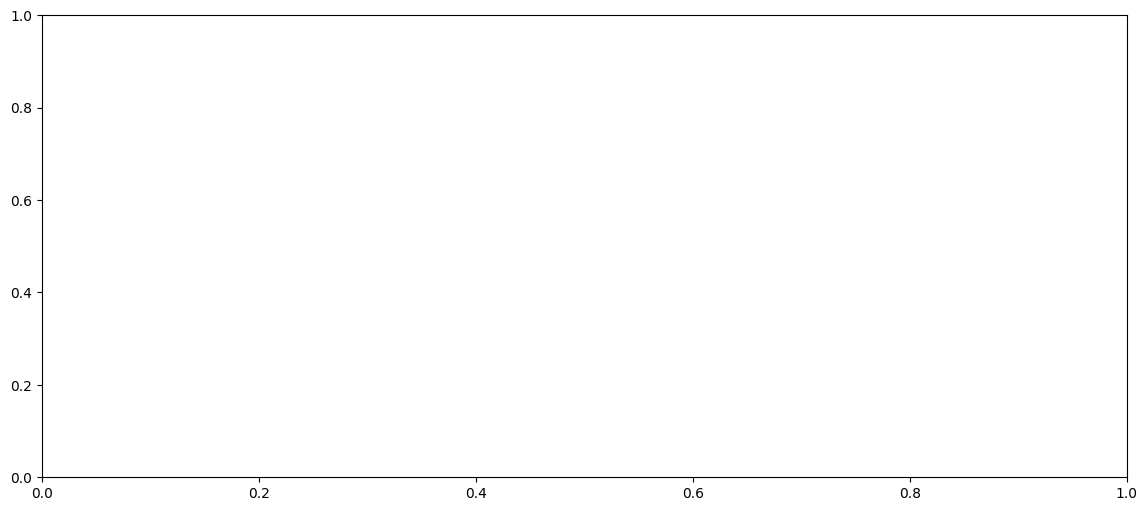

In [16]:
# Coordenadas paralelas
try:
    from optuna.visualization.matplotlib import plot_parallel_coordinate
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_parallel_coordinate(study_tpe, ax=ax)
    ax.set_title('Coordenadas paralelas — TPE (color = val_accuracy)')
    plt.tight_layout()
    plt.show()
except Exception:
    print('plot_parallel_coordinate requiere optuna>=3.0 con matplotlib backend.')

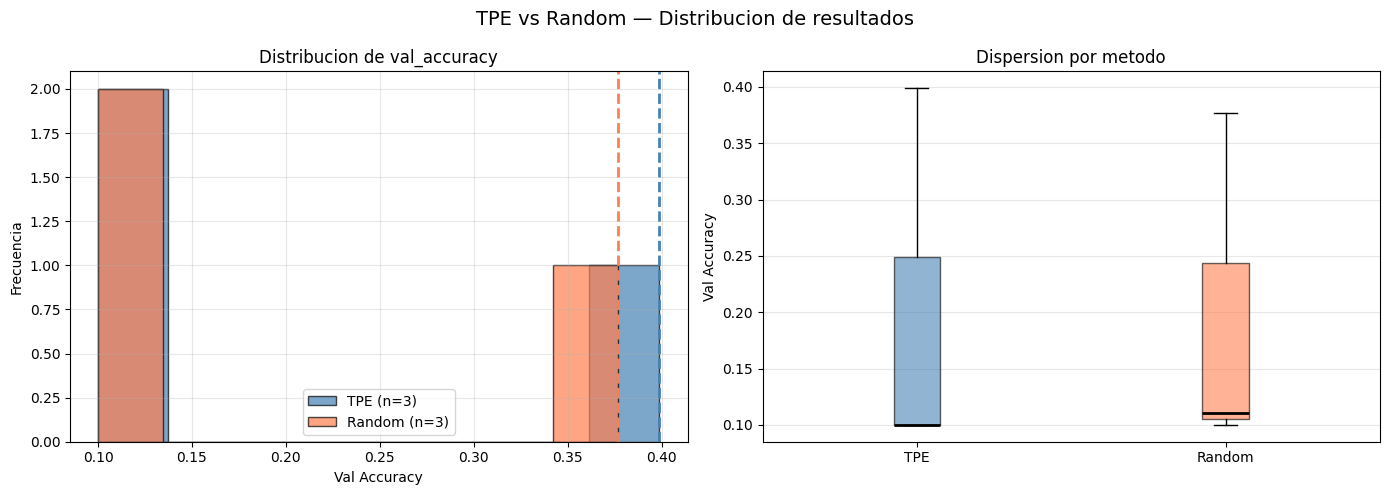


Metrica                                   TPE         Random
Mejor val_accuracy                     0.3989         0.3769
Media val_accuracy                     0.1996         0.1957
Mediana                                0.1000         0.1101
Std                                    0.1409         0.1282
Completados                                 3              3
Podados                                     0              0
Tiempo (s)                              395.9          418.0


In [17]:
# Distribucion val_accuracy: TPE vs Random
tpe_vals    = [t.value for t in study_tpe.trials    if t.state == optuna.trial.TrialState.COMPLETE]
random_vals = [t.value for t in study_random.trials if t.state == optuna.trial.TrialState.COMPLETE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tpe_vals,    bins=8, alpha=0.7, color='steelblue', edgecolor='black',
             label=f'TPE (n={len(tpe_vals)})')
axes[0].hist(random_vals, bins=8, alpha=0.7, color='coral',     edgecolor='black',
             label=f'Random (n={len(random_vals)})')
if tpe_vals:    axes[0].axvline(max(tpe_vals),    color='steelblue', linestyle='--', linewidth=2)
if random_vals: axes[0].axvline(max(random_vals), color='coral',     linestyle='--', linewidth=2)
axes[0].set_title('Distribucion de val_accuracy')
axes[0].set_xlabel('Val Accuracy'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

data_box  = [d for d in [tpe_vals, random_vals] if d]
labels_box = [l for l, d in [('TPE', tpe_vals), ('Random', random_vals)] if d]
if data_box:
    bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    colors_box = ['steelblue', 'coral']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_title('Dispersion por metodo')
axes[1].set_ylabel('Val Accuracy'); axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('TPE vs Random — Distribucion de resultados', fontsize=14)
plt.tight_layout()
plt.show()

# Tabla comparativa
def safe_stat(lst, fn): return fn(lst) if lst else float('nan')
print('\n' + '=' * 60)
print(f'{"Metrica":<30} {"TPE":>14} {"Random":>14}')
print('=' * 60)
for label, fn in [('Mejor val_accuracy', max), ('Media val_accuracy', np.mean),
                   ('Mediana',  np.median), ('Std', np.std)]:
    print(f'{label:<30} {safe_stat(tpe_vals, fn):>14.4f} {safe_stat(random_vals, fn):>14.4f}')
print(f'{"Completados":<30} {len(tpe_vals):>14} {len(random_vals):>14}')
print(f'{"Podados":<30} {n_pruned_tpe:>14} {n_pruned_rnd:>14}')
print(f'{"Tiempo (s)":<30} {t_tpe_elapsed:>14.1f} {t_rand_elapsed:>14.1f}')
print('=' * 60)

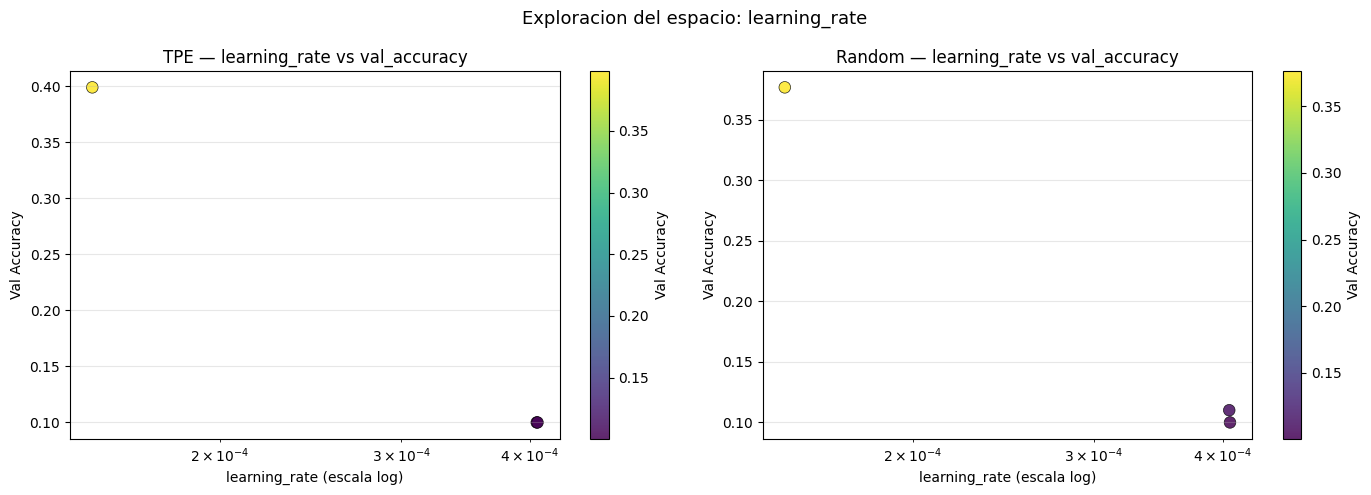

In [18]:
# Scatter: learning_rate vs val_accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, study, label, color in [
    (axes[0], study_tpe,    'TPE',    'steelblue'),
    (axes[1], study_random, 'Random', 'coral')
]:
    complete = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if not complete:
        ax.set_title(f'{label} — sin trials completados'); continue
    lrs  = [t.params['learning_rate'] for t in complete]
    accs = [t.value for t in complete]
    sc = ax.scatter(lrs, accs, c=accs, cmap='viridis', s=70,
                    edgecolors='black', linewidth=0.5, alpha=0.85)
    plt.colorbar(sc, ax=ax, label='Val Accuracy')
    ax.set_xscale('log')
    ax.set_title(f'{label} — learning_rate vs val_accuracy')
    ax.set_xlabel('learning_rate (escala log)'); ax.set_ylabel('Val Accuracy')
    ax.grid(True, alpha=0.3)

plt.suptitle('Exploracion del espacio: learning_rate', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Top 5 trials del estudio TPE
complete_tpe = [t for t in study_tpe.trials if t.state == optuna.trial.TrialState.COMPLETE]
top5 = sorted(complete_tpe, key=lambda t: t.value, reverse=True)[:5]

print('Top 5 trials — estudio TPE:')
print(f'{"Trial":>6} {"Val Acc":>10} | Hiperparametros')
print('-' * 80)
for t in top5:
    params_str = ', '.join(f'{k}={v}' for k, v in t.params.items())
    print(f'{t.number:>6} {t.value:>10.4f} | {params_str}')

Top 5 trials — estudio TPE:
 Trial    Val Acc | Hiperparametros
--------------------------------------------------------------------------------
     2     0.3989 | filters1=96, filters2=96, filters3=256, dense_units=256, dropout1=0.2793699936433256, dropout2=0.6226559822580909, learning_rate=0.00015030900645056822, l2_reg=2.4658447214487366e-05, use_batch_norm=False
     0     0.1000 | filters1=48, filters2=192, filters3=192, dense_units=128, dropout1=0.1545474901621302, dropout2=0.3641915784487018, learning_rate=0.0004059611610484307, l2_reg=0.00011207606211860574, use_batch_norm=True
     1     0.1000 | filters1=32, filters2=96, filters3=256, dense_units=512, dropout1=0.3896896099223679, dropout2=0.5829390718407614, learning_rate=0.0004066563313514797, l2_reg=1.5679933916722995e-05, use_batch_norm=True


## Entrenamiento Final con la Mejor Configuracion

Reentrenamos sobre todos los datos de train con augmentation completa.

In [20]:
# Seleccionar mejor estudio
best_val_tpe    = study_tpe.best_value    if study_tpe.best_trial    else -1
best_val_random = study_random.best_value if study_random.best_trial else -1

if best_val_tpe >= best_val_random:
    best_study = study_tpe;    best_label = 'TPE'
else:
    best_study = study_random; best_label = 'Random'

best_params = best_study.best_params
print(f'Mejor estudio : {best_label} (val_acc={best_study.best_value:.4f})')
print('Hiperparametros finales:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Reconstruir modelo con los mejores params
class FrozenTrial:
    def __init__(self, params): self._p = params
    def suggest_categorical(self, name, choices): return self._p[name]
    def suggest_float(self, name, low, high, **kw): return self._p[name]

tf.keras.backend.clear_session()
final_model = build_cnn_from_trial(FrozenTrial(best_params))
final_model.summary()
print(f'\nParametros totales: {final_model.count_params():,}')

Mejor estudio : TPE (val_acc=0.3989)
Hiperparametros finales:
  filters1: 96
  filters2: 96
  filters3: 256
  dense_units: 256
  dropout1: 0.2793699936433256
  dropout2: 0.6226559822580909
  learning_rate: 0.00015030900645056822
  l2_reg: 2.4658447214487366e-05
  use_batch_norm: False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,114,730 (8.07 MB)

 Trainable params: 2,114,730 (8.07 MB)

 Non-trainable params: 0 (0.00 B)


Parametros totales: 2,114,730


In [ ]:
t_final_start = time.time()

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE_FINAL,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=0
    )
]

print(f'Entrenando modelo final — Optuna {best_label}')
print(f'  Batch: {BATCH_FINAL}  |  Max epocas: {EPOCHS_FULL}  |  EarlyStopping patience: {PATIENCE_FINAL}')

history = final_model.fit(
    datagen_full.flow(X_train, y_train, batch_size=BATCH_FINAL),
    steps_per_epoch=len(X_train) // BATCH_FINAL,
    epochs=EPOCHS_FULL,
    validation_data=(X_val, y_val),
    callbacks=cb_list,
    verbose=1
)

t_final_elapsed = time.time() - t_final_start

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title(f'Accuracy — Final (Optuna {best_label})')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title(f'Loss — Final (Optuna {best_label})')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

n_epochs_ran = len(history.history['accuracy'])
best_val_acc = max(history.history['val_accuracy'])
gap = history.history['accuracy'][-1] - best_val_acc
print(f'Epocas entrenadas   : {n_epochs_ran}')
print(f'Mejor Val Accuracy  : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'Gap train-val       : {gap:.4f}')
print(f'Tiempo entrenamiento: {t_final_elapsed:.1f}s ({t_final_elapsed/60:.1f} min)')

Entrenando modelo final — Optuna TPE
  Batch: 128  |  Max epocas: 35  |  EarlyStopping patience: 6
Epoch 1/35
328/328 ━━━━━━━━━━━━━━━━━━━━ 137s 411ms/step - accuracy: 0.1809 - loss: 2.1746 - val_accuracy: 0.3507 - val_loss: 1.7993 - learning_rate: 1.5031e-04
Epoch 2/35
328/328 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.3203 - loss: 1.7237 - val_accuracy: 0.3702 - val_loss: 1.7325 - learning_rate: 1.5031e-04
Epoch 3/35
328/328 ━━━━━━━━━━━━━━━━━━━━ 137s 418ms/step - accuracy: 0.3555 - loss: 1.7602 - val_accuracy: 0.4553 - val_loss: 1.4754 - learning_rate: 1.5031e-04
Epoch 4/35
328/328 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4141 - loss: 1.6864 - val_accuracy: 0.4554 - val_loss: 1.4800 - learning_rate: 1.5031e-04
Epoch 5/35
328/328 ━━━━━━━━━━━━━━━━━━━━ 137s 418ms/step - accuracy: 0.4198 - loss: 1.6023 - val_accuracy: 0.5138 - val_loss: 1.3334 - learning_rate: 1.5031e-04
Epoch 6/35
328/328 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4453 - loss: 1.6069 - val_accuracy: 0.

In [ ]:
# Resumen de tiempos
t_total = time.time() - NOTEBOOK_START
print('=' * 45)
print('RESUMEN DE TIEMPOS')
print('=' * 45)
print(f'  Estudio TPE    : {t_tpe_elapsed:6.1f}s = {t_tpe_elapsed/60:.1f} min')
print(f'  Estudio Random : {t_rand_elapsed:6.1f}s = {t_rand_elapsed/60:.1f} min')
print(f'  Entrenamiento  : {t_final_elapsed:6.1f}s = {t_final_elapsed/60:.1f} min')
print(f'  TOTAL          : {t_total:6.1f}s = {t_total/60:.1f} min')
print('=' * 45)
if t_total <= 900:
    print(f'Dentro del presupuesto de 15 min.')
else:
    print(f'Excede 15 min por {(t_total-900)/60:.1f} min. Reduce N_TRIALS o TRIAL_EPOCHS.')

## Evaluacion en Test Set

In [ ]:
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)

t0 = time.time()
y_pred_proba = final_model.predict(X_test, verbose=0)
inference_ms = (time.time() - t0) / len(X_test) * 1000

y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

print('=' * 55)
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')
print(f'Inferencia    : {inference_ms:.3f} ms / imagen')
print(f'Parametros    : {final_model.count_params():,}')
print('=' * 55)
n_correct = (y_pred == y_true).sum()
print(f'Correctas: {n_correct} / {len(y_true)} ({n_correct/len(y_true)*100:.2f}%)')

In [ ]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusion — Absoluta')
axes[0].set_xlabel('Prediccion'); axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusion — Normalizada')
axes[1].set_xlabel('Prediccion'); axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(f'Test — Accuracy: {test_acc*100:.2f}% (Optuna {best_label})', fontsize=14)
plt.tight_layout(); plt.show()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
error_mask    = y_pred != y_true
error_indices = np.where(error_mask)[0]
error_probs   = y_pred_proba[error_indices, y_pred[error_indices]]
top_err       = error_indices[np.argsort(error_probs)[::-1][:20]]

print(f'Total errores: {len(error_indices)} ({len(error_indices)/len(y_true)*100:.2f}%)')

fig, axes = plt.subplots(4, 5, figsize=(15, 13))
for i, idx in enumerate(top_err):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx])
    conf = y_pred_proba[idx, y_pred[idx]] * 100
    ax.set_title(f'Real: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]} ({conf:.1f}%)',
                 fontsize=8, color='red')
    ax.axis('off')
plt.suptitle(f'Top 20 errores — Optuna {best_label}', fontsize=13)
plt.tight_layout(); plt.show()

## Guardado

In [ ]:
MODEL_PATH   = 'best_cnn_cifar10_optuna.keras'
RESULTS_PATH = 'optuna_results_cifar10.json'

final_model.save(MODEL_PATH)
print(f'Modelo guardado: {MODEL_PATH}')

def serialize_trials(study):
    return [{
        'number': t.number, 'state': t.state.name,
        'value': float(t.value) if t.value is not None else None,
        'params': {k: (v.item() if hasattr(v, 'item') else v) for k, v in t.params.items()}
    } for t in study.trials]

results = {
    'dataset': 'CIFAR-10',
    'time_budget': {
        'search_ratio': SEARCH_RATIO, 'trial_epochs': TRIAL_EPOCHS,
        'trial_batch': TRIAL_BATCH, 'timeout_tpe': TIMEOUT_TPE,
        'timeout_random': TIMEOUT_RANDOM, 'epochs_full': EPOCHS_FULL,
        'batch_final': BATCH_FINAL
    },
    'timing': {
        'tpe_s': float(t_tpe_elapsed), 'random_s': float(t_rand_elapsed),
        'final_s': float(t_final_elapsed), 'total_s': float(t_total)
    },
    'tpe_study': {
        'n_trials': N_TRIALS_TPE, 'timeout': TIMEOUT_TPE,
        'best_val_accuracy': float(study_tpe.best_value),
        'best_params': {k: (v.item() if hasattr(v, 'item') else v)
                        for k, v in study_tpe.best_params.items()},
        'trials': serialize_trials(study_tpe)
    },
    'random_study': {
        'n_trials': N_TRIALS_RANDOM, 'timeout': TIMEOUT_RANDOM,
        'best_val_accuracy': float(study_random.best_value),
        'best_params': {k: (v.item() if hasattr(v, 'item') else v)
                        for k, v in study_random.best_params.items()},
        'trials': serialize_trials(study_random)
    },
    'final_model': {
        'source': best_label,
        'best_params': {k: (v.item() if hasattr(v, 'item') else v)
                        for k, v in best_params.items()},
        'test_accuracy': float(test_acc), 'test_loss': float(test_loss),
        'inference_ms': float(inference_ms),
        'total_params': int(final_model.count_params())
    }
}

with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f'Resultados guardados: {RESULTS_PATH}')

loaded = keras.models.load_model(MODEL_PATH)
_, loaded_acc = loaded.evaluate(X_test, y_test, verbose=0)
print(f'Verificacion: {loaded_acc:.4f} ({loaded_acc*100:.2f}%)')
print(f'\nTiempo total del notebook: {t_total:.1f}s = {t_total/60:.1f} min')

## Resumen Final

### Comparativa de metodos

| Metodo | Aprende | Pruning | Params continuos | Escalabilidad |
|---|---|---|---|---|
| Grid Search | No | No | No (discretos) | Exponencial |
| Random Search | No | No | Si | Alta |
| **Optuna TPE** | **Si** | **Si** | **Si** | **Alta** |
| Optuna Random | No | **Si** | **Si** | Alta |

### Por que TPE gana (generalmente)

1. **Explora primero** (8 trials aleatorios para calentar), luego **explota** — propone configs cerca de las zonas que ya han dado buenos resultados.
2. **El pruning multiplica los trials utiles** — con el mismo tiempo, TPE ve mas configuraciones porque corta rapido las malas.
3. **Maneja parametros continuos nativamente** — `dropout` y `learning_rate` son floats, no listas discretas.

### Ajuste del presupuesto de tiempo

Si necesitas mas velocidad: baja `SEARCH_RATIO` a 0.12-0.15 y `TRIAL_EPOCHS` a 8.  
Si tienes mas tiempo (30 min+): sube `N_TRIALS_TPE` a 40 y `EPOCHS_FULL` a 50.